In [1]:
from google.colab import files

uploaded = files.upload()

Saving data_dictionary.csv to data_dictionary.csv
Saving diagnoses.csv to diagnoses.csv
Saving encounters.csv to encounters.csv
Saving labs.csv to labs.csv
Saving medications.csv to medications.csv
Saving patients.csv to patients.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

patients = pd.read_csv("patients.csv")
encounters = pd.read_csv("encounters.csv")
labs = pd.read_csv("labs.csv")
diagnoses = pd.read_csv("diagnoses.csv")
medications = pd.read_csv("medications.csv")
data_dictionary = pd.read_csv("data_dictionary.csv")

print("Patients:", patients.shape)
print("Encounters:", encounters.shape)
print("Labs:", labs.shape)
print("Diagnoses:", diagnoses.shape)
print("Medications:", medications.shape)
print("Data Dictionary:", data_dictionary.shape)

Patients: (12000, 7)
Encounters: (30000, 6)
Labs: (90000, 5)
Diagnoses: (45000, 5)
Medications: (36000, 5)
Data Dictionary: (28, 3)


In [3]:
#Checking data types and missing values
datasets = {
    "patients": patients,
    "encounters": encounters,
    "labs": labs,
    "diagnoses": diagnoses,
    "medications": medications
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isna().sum())


PATIENTS
Patient_ID            int64
Age                   int64
Gender               object
Risk_Category        object
Primary_Condition    object
Region               object
Age_Group            object
dtype: object

Missing values:
Patient_ID           0
Age                  0
Gender               0
Risk_Category        0
Primary_Condition    0
Region               0
Age_Group            0
dtype: int64

ENCOUNTERS
Encounter_ID            int64
Patient_ID              int64
Encounter_Date         object
Encounter_Type         object
Length_of_Stay_Days     int64
Outcome                object
dtype: object

Missing values:
Encounter_ID           0
Patient_ID             0
Encounter_Date         0
Encounter_Type         0
Length_of_Stay_Days    0
Outcome                0
dtype: int64

LABS
Lab_ID            int64
Patient_ID        int64
Lab_Date         object
Test_Name        object
Result_Value    float64
dtype: object

Missing values:
Lab_ID            0
Patient_ID        0
Lab_Da

In [ ]:
#Converting date columns
encounters["Encounter_Date"] = pd.to_datetime(encounters["Encounter_Date"])
labs["Lab_Date"] = pd.to_datetime(labs["Lab_Date"])
diagnoses["Diagnosis_Date"] = pd.to_datetime(diagnoses["Diagnosis_Date"])
medications["Medication_Date"] = pd.to_datetime(medications["Medication_Date"])

print(encounters["Encounter_Date"].dtype)
print(labs["Lab_Date"].dtype)
print(diagnoses["Diagnosis_Date"].dtype)
print(medications["Medication_Date"].dtype)

In [8]:
#Creating analysis-ready clean datasets
patients_clean = patients[
    patients["Gender"] != "Unknown"
].copy()

encounters_clean = encounters[
    encounters["Outcome"] != "Unknown"
].copy()

diagnoses_clean = diagnoses[
    diagnoses["Diagnosis_Code"] != "UNK"
].copy()

labs_clean = labs[
    labs["Result_Value"].notna()
].copy()

# Useful time fields
encounters_clean["Year"] = encounters_clean["Encounter_Date"].dt.year
encounters_clean["Month"] = encounters_clean["Encounter_Date"].dt.month
encounters_clean["Year_Month"] = encounters_clean["Encounter_Date"].dt.to_period("M").astype(str)

labs_clean["Year"] = labs_clean["Lab_Date"].dt.year
labs_clean["Year_Month"] = labs_clean["Lab_Date"].dt.to_period("M").astype(str)

print("Patients clean:", patients_clean.shape)
print("Encounters clean:", encounters_clean.shape)
print("Labs clean:", labs_clean.shape)
print("Diagnoses clean:", diagnoses_clean.shape)

Patients clean: (11940, 7)
Encounters clean: (29910, 9)
Labs clean: (89880, 7)
Diagnoses clean: (44925, 5)


In [9]:
#Patient population analysis
patient_summary = {
    "Total Patients": len(patients),
    "Average Age": round(patients["Age"].mean(), 1),
    "Female Patients": (patients_clean["Gender"] == "Female").sum(),
    "Male Patients": (patients_clean["Gender"] == "Male").sum(),
    "High Risk Patients": (patients["Risk_Category"] == "High").sum(),
    "Medium Risk Patients": (patients["Risk_Category"] == "Medium").sum(),
    "Low Risk Patients": (patients["Risk_Category"] == "Low").sum()
}

patient_summary

{'Total Patients': 12000,
 'Average Age': np.float64(51.9),
 'Female Patients': np.int64(6138),
 'Male Patients': np.int64(5802),
 'High Risk Patients': np.int64(2369),
 'Medium Risk Patients': np.int64(5448),
 'Low Risk Patients': np.int64(4183)}

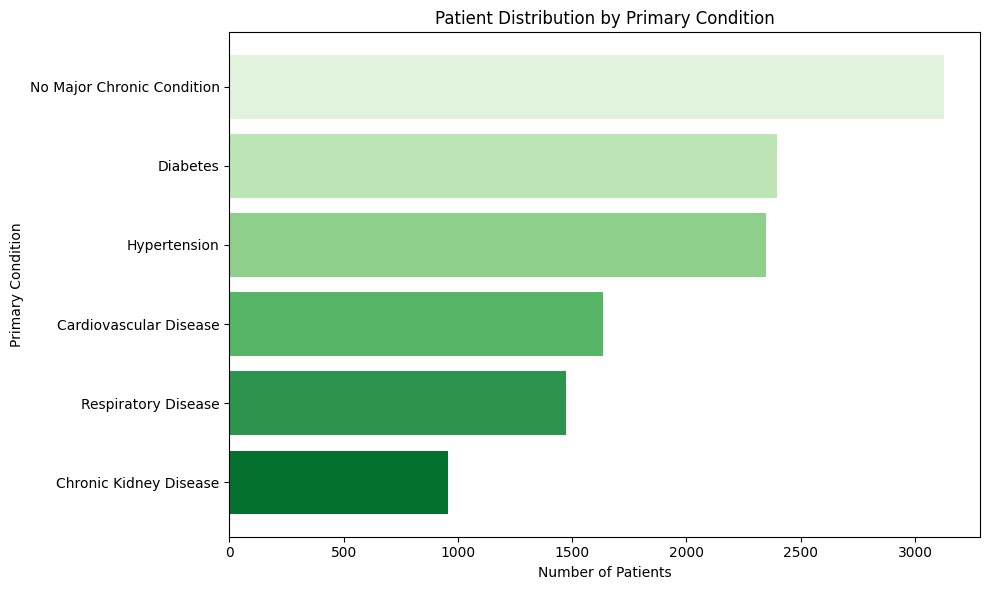

In [13]:
#Visualize patient distribution by primary condition
condition_counts = (
    patients_clean["Primary_Condition"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    condition_counts.index,
    condition_counts.values, color=sns.color_palette("Greens_r", len(condition_counts))
)

plt.title("Patient Distribution by Primary Condition")
plt.xlabel("Number of Patients")
plt.ylabel("Primary Condition")

plt.tight_layout()
plt.show()

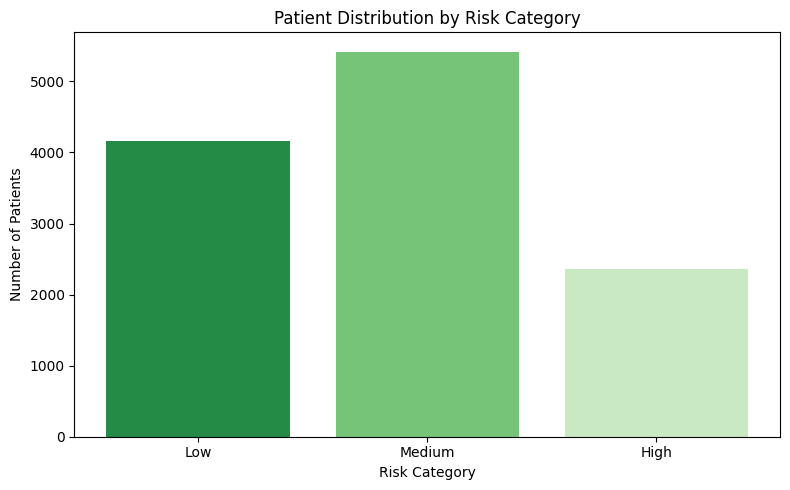

In [14]:
#Risk category visualization
risk_counts = (
    patients_clean["Risk_Category"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

plt.figure(figsize=(8, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values, color=sns.color_palette("Greens_r", len(risk_counts))
)

plt.title("Patient Distribution by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

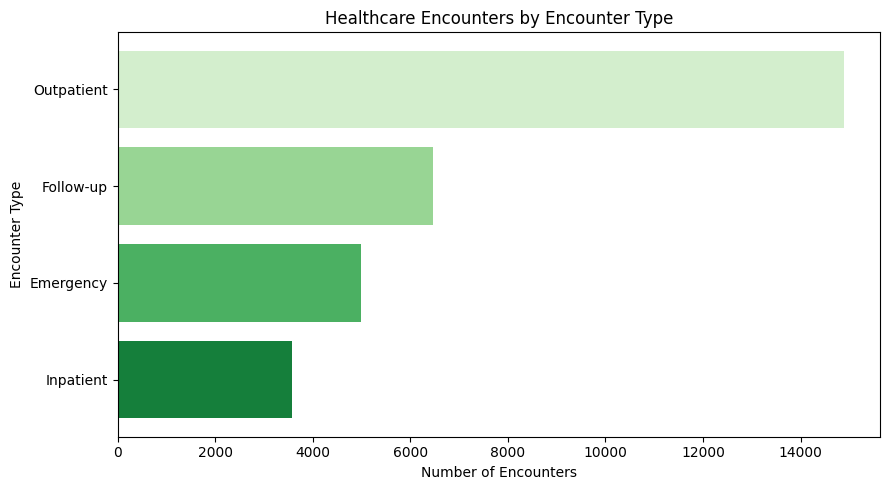

In [15]:
#Encounter utilization analysis
encounter_counts = (
    encounters_clean["Encounter_Type"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

plt.barh(
    encounter_counts.index,
    encounter_counts.values, color=sns.color_palette("Greens_r", len(encounter_counts))
)

plt.title("Healthcare Encounters by Encounter Type")
plt.xlabel("Number of Encounters")
plt.ylabel("Encounter Type")

plt.tight_layout()
plt.show()

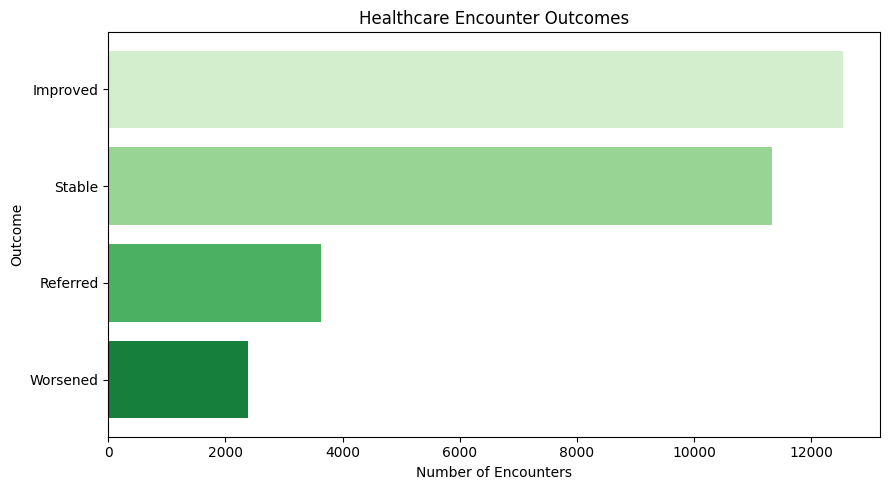

In [16]:
#Encounter outcomes visualization
outcome_counts = (
    encounters_clean["Outcome"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

plt.barh(
    outcome_counts.index,
    outcome_counts.values, color=sns.color_palette("Greens_r", len(outcome_counts))
)

plt.title("Healthcare Encounter Outcomes")
plt.xlabel("Number of Encounters")
plt.ylabel("Outcome")

plt.tight_layout()
plt.show()

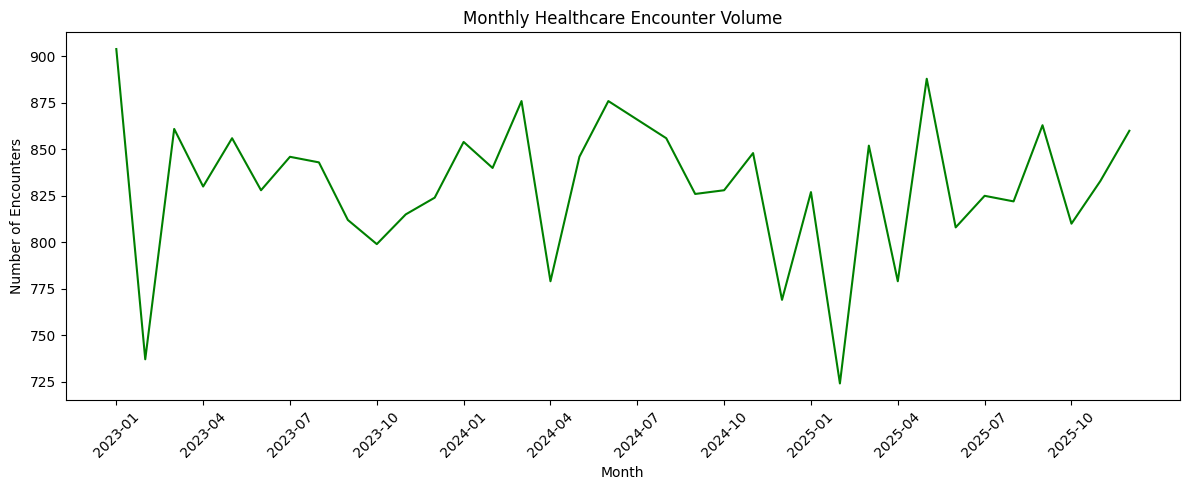

In [20]:
#Monthly encounter trend
monthly_trend = (
    encounters_clean
    .groupby("Year_Month")
    .size()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_trend.index,
    monthly_trend.values, color='Green'
)

plt.title("Monthly Healthcare Encounter Volume")
plt.xlabel("Month")
plt.ylabel("Number of Encounters")

plt.xticks(
    monthly_trend.index[::3],
    rotation=45
)

plt.tight_layout()
plt.show()

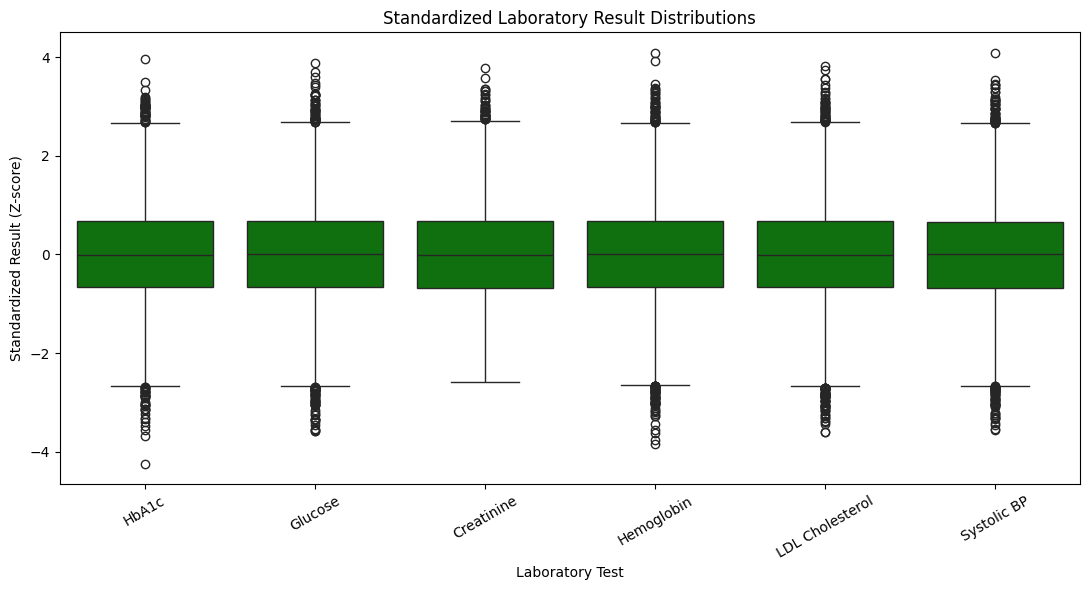

In [22]:
#Compare laboratory result distributions
lab_plot = labs_clean.copy()

lab_plot["Standardized_Result"] = (
    lab_plot.groupby("Test_Name")["Result_Value"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

lab_order = [
    "HbA1c",
    "Glucose",
    "Creatinine",
    "Hemoglobin",
    "LDL Cholesterol",
    "Systolic BP"
]

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=lab_plot,
    x="Test_Name",
    y="Standardized_Result",
    order=lab_order, color='Green'
)

plt.title("Standardized Laboratory Result Distributions")
plt.xlabel("Laboratory Test")
plt.ylabel("Standardized Result (Z-score)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

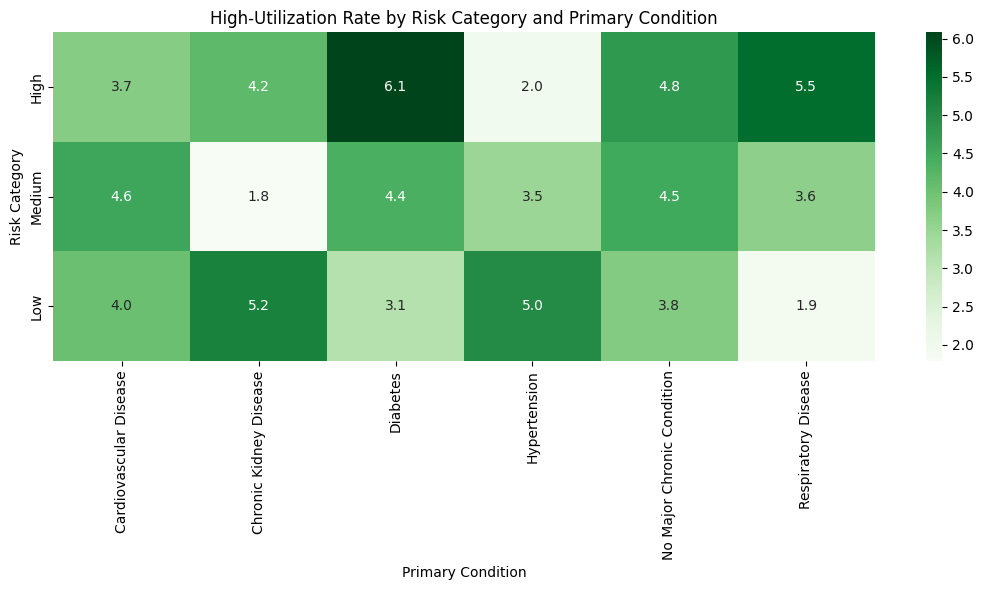

In [24]:
#High-utilization heatmap
patient_utilization = (
    encounters
    .groupby("Patient_ID")
    .size()
    .reset_index(name="Encounter_Count")
)

utilization_analysis = patients.copy()

utilization_analysis = utilization_analysis.merge(
    patient_utilization,
    on="Patient_ID",
    how="left"
)

utilization_analysis["Encounter_Count"] = (
    utilization_analysis["Encounter_Count"]
    .fillna(0)
)

utilization_analysis["High_Utilization"] = (
    utilization_analysis["Encounter_Count"] >= 6
)

heatmap_data = (
    utilization_analysis
    .groupby(["Risk_Category", "Primary_Condition"])["High_Utilization"]
    .mean()
    .unstack()
    .mul(100)
)

heatmap_data = heatmap_data.reindex(
    ["High", "Medium", "Low"]
)

plt.figure(figsize=(11, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",  cmap="Greens"
)

plt.title("High-Utilization Rate by Risk Category and Primary Condition")
plt.xlabel("Primary Condition")
plt.ylabel("Risk Category")

plt.tight_layout()
plt.show()

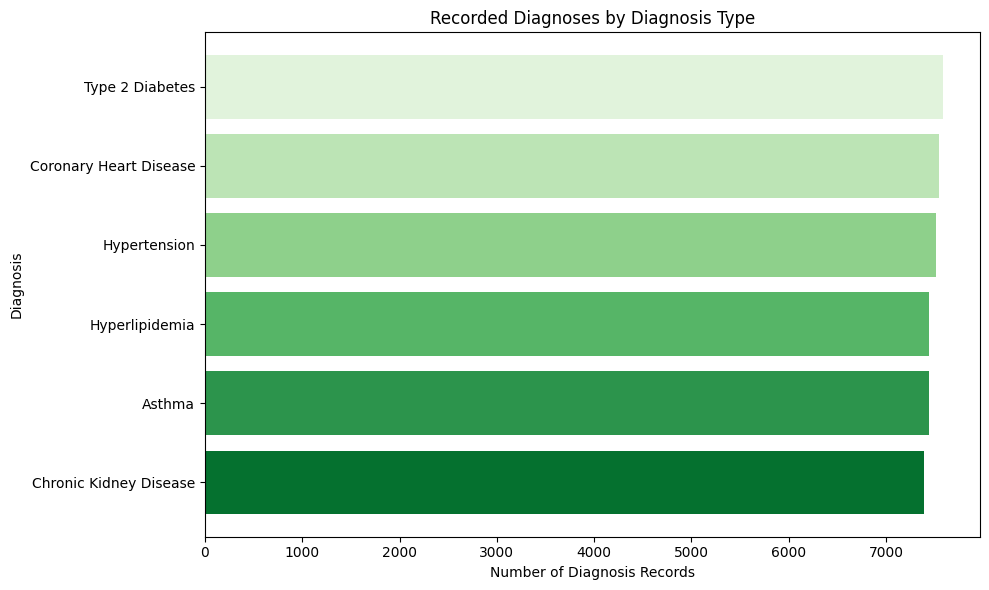

In [26]:
#Diagnosis prevalence
diagnosis_counts = (
    diagnoses_clean["Diagnosis_Name"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    diagnosis_counts.index,
    diagnosis_counts.values, color=sns.color_palette("Greens_r", len(diagnosis_counts))
)

plt.title("Recorded Diagnoses by Diagnosis Type")
plt.xlabel("Number of Diagnosis Records")
plt.ylabel("Diagnosis")

plt.tight_layout()
plt.show()

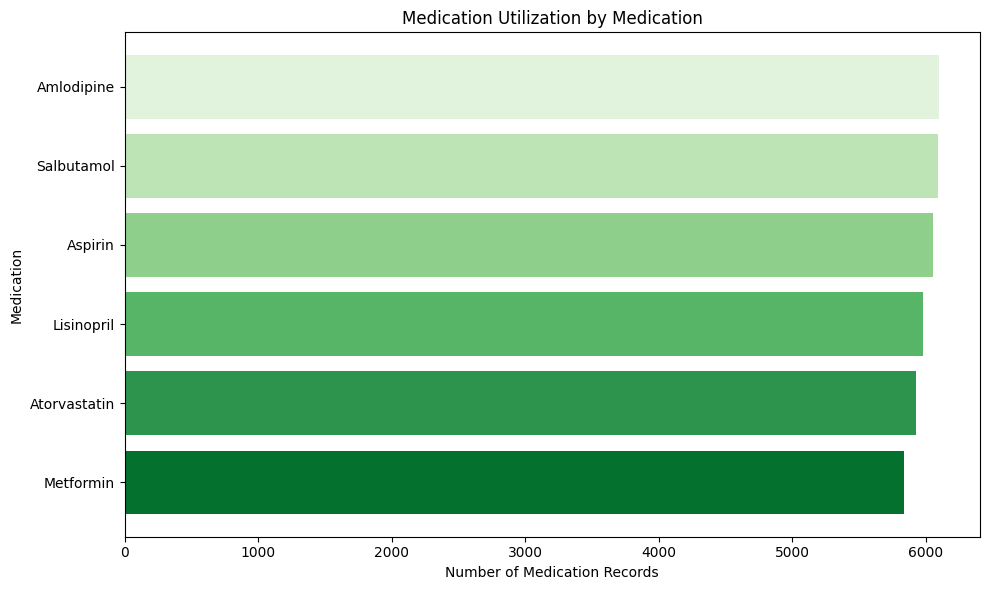

In [28]:
#Medication utilization
medication_counts = (
    medications["Medication_Name"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    medication_counts.index,
    medication_counts.values, color=sns.color_palette("Greens_r", len(medication_counts))
)

plt.title("Medication Utilization by Medication")
plt.xlabel("Number of Medication Records")
plt.ylabel("Medication")

plt.tight_layout()
plt.show()

In [29]:
#Python summary

high_utilization_count = (
    utilization_analysis["High_Utilization"].sum()
)

final_summary = pd.DataFrame({
    "Metric": [
        "Total Patients",
        "Average Age",
        "Total Encounters",
        "Average Encounters per Patient",
        "Emergency Encounter Rate",
        "Inpatient Encounter Rate",
        "Improvement Rate",
        "Worsening Rate",
        "High-Utilization Patients",
        "High-Utilization Rate",
        "Laboratory Records",
        "Missing Laboratory Results",
        "Diagnosis Records",
        "Medication Records"
    ],
    "Value": [
        len(patients),
        round(patients["Age"].mean(), 1),
        len(encounters),
        round(encounters["Patient_ID"].count() / encounters["Patient_ID"].nunique(), 2),
        round((encounters["Encounter_Type"] == "Emergency").mean() * 100, 2),
        round((encounters["Encounter_Type"] == "Inpatient").mean() * 100, 2),
        round((encounters_clean["Outcome"] == "Improved").mean() * 100, 2),
        round((encounters_clean["Outcome"] == "Worsened").mean() * 100, 2),
        high_utilization_count,
        round(high_utilization_count / len(patients) * 100, 2),
        len(labs),
        labs["Result_Value"].isna().sum(),
        len(diagnoses),
        len(medications)
    ]
})

print(final_summary)

final_summary.to_csv(
    "healthcare_clinical_analysis_summary.csv",
    index=False
)

                            Metric     Value
0                   Total Patients  12000.00
1                      Average Age     51.90
2                 Total Encounters  30000.00
3   Average Encounters per Patient      2.72
4         Emergency Encounter Rate     16.66
5         Inpatient Encounter Rate     11.97
6                 Improvement Rate     41.96
7                   Worsening Rate      7.97
8        High-Utilization Patients    479.00
9            High-Utilization Rate      3.99
10              Laboratory Records  90000.00
11      Missing Laboratory Results    120.00
12               Diagnosis Records  45000.00
13              Medication Records  36000.00


In [30]:
#powerbi dataset preparation
# Create patient-level utilization metrics
patient_utilization = (
    encounters
    .groupby("Patient_ID")
    .agg(
        Encounter_Count=("Encounter_ID", "count"),
        Emergency_Encounters=("Encounter_Type", lambda x: (x == "Emergency").sum()),
        Inpatient_Encounters=("Encounter_Type", lambda x: (x == "Inpatient").sum())
    )
    .reset_index()
)

# Create diagnosis count per patient
patient_diagnosis = (
    diagnoses_clean
    .groupby("Patient_ID")
    .agg(
        Distinct_Diagnoses=("Diagnosis_Code", "nunique")
    )
    .reset_index()
)

# Create medication metrics per patient
patient_medication = (
    medications
    .groupby("Patient_ID")
    .agg(
        Medication_Records=("Medication_ID", "count"),
        Active_Medications=("Medication_Status", lambda x: (x == "Active").sum())
    )
    .reset_index()
)

# Enrich encounters with patient information
powerbi_data = (
    encounters
    .merge(
        patients_clean,
        on="Patient_ID",
        how="left"
    )
    .merge(
        patient_utilization,
        on="Patient_ID",
        how="left"
    )
    .merge(
        patient_diagnosis,
        on="Patient_ID",
        how="left"
    )
    .merge(
        patient_medication,
        on="Patient_ID",
        how="left"
    )
)

# High-utilization classification
powerbi_data["High_Utilization"] = (
    powerbi_data["Encounter_Count"] >= 6
)

print("Power BI dataset shape:", powerbi_data.shape)
print("\nColumns:")
print(powerbi_data.columns.tolist())

Power BI dataset shape: (30000, 19)

Columns:
['Encounter_ID', 'Patient_ID', 'Encounter_Date', 'Encounter_Type', 'Length_of_Stay_Days', 'Outcome', 'Age', 'Gender', 'Risk_Category', 'Primary_Condition', 'Region', 'Age_Group', 'Encounter_Count', 'Emergency_Encounters', 'Inpatient_Encounters', 'Distinct_Diagnoses', 'Medication_Records', 'Active_Medications', 'High_Utilization']


In [31]:
powerbi_data.to_csv(
    "encounters_enriched.csv",
    index=False
)

print("Export complete")
print("Rows:", len(powerbi_data))
print("Columns:", len(powerbi_data.columns))

Export complete
Rows: 30000
Columns: 19
